# Case study E4: ALTRO

ALTRO (Howell, Jackson and Manchester, IROS 2019) solves constrained trajectory optimization in two
phases:

1. **augmented-Lagrangian iLQR**: iLQR on the augmented Lagrangian of the problem, with multiplier
   and penalty updates in an outer loop, until the constraints hold to a loose tolerance;
2. **projected Newton**: the states and controls become free variables, and Newton steps project the
   trajectory onto the active constraints, polishing the violation to a tight tolerance.

Its reference implementation is Altro.jl, now at 0.5, fast because of ForwardDiff and StaticArrays.
Scaly writes both phases as one generated C function (`al_ilqr.py`): every loop is a Scaly
`while_loop` or `scan`, the derivatives come from AD, and the projection factors a sparse KKT matrix
with the generated `L D L'`. The logic follows Altro.jl's source, so the two produce the same iterates.

The problems are the paper's parallel park and cartpole, in their 2019 definitions. The Scaly cells
below run without Julia. The Altro.jl cells need `baseline/setup.sh` and are off by default
(`RUN_BASELINES`); the recorded results in `results/` are shown instead. The write-up is
`internal/notes/case_study_e4_report.html`.

In [1]:
import json
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd()
sys.path[:0] = [str(HERE), str(HERE.parents[1] / "notebooks")]

import plotstyle
from scaly.codegen import render_c_module

import scaly_impl

plotstyle.use()
RUN_BASELINES = False  # True reruns compare.py: both problems, both algorithms, both implementations, 3 processes each (about 10 minutes)
RESULTS = HERE / "results"

## The problems

Both use explicit third-order Runge-Kutta (Kutta's), a quadratic cost toward the goal whose stage
terms carry the factor $\Delta t$, bounds, and the goal as an equality at the last knot.

- **Parallel park**: a Dubins car, $x = (p_x, p_y, \theta)$, $u = (v, \omega)$, 51 knots of 0.06 s,
  from the origin to $(0, 1, 0)$ with $|u| \le 2$, $|p_x| \le 0.25$ and $-0.001 \le p_y \le 1.001$
  from the second knot on: the car must move sideways inside a narrow slot. The initial controls are
  all ones.
- **Cartpole**: the swing-up, $x = (s, \theta, \dot s, \dot\theta)$, $u$ the force, 101 knots over
  5 s, $|u| \le 3$, from rest to $\theta = \pi$. The initial controls are 0.01.

`scaly_impl.py` states each as an `al_ilqr.OCP`: the model, the weights and one inequality function
per stage with a mask saying which rows apply where.

In [2]:
for name, make in scaly_impl.PROBLEMS.items():
  ocp = make()
  print(f"{name}: nx={ocp.nx}, nu={ocp.nu}, N={ocp.n_knots}, dt={ocp.dt:.3f}, {ocp.nc} inequality rows per stage, "
        f"{int(ocp.masks.sum())} applied in all")

parallel_park: nx=3, nu=2, N=51, dt=0.060, 8 inequality rows per stage, 396 applied in all
cartpole: nx=4, nu=1, N=101, dt=0.050, 2 inequality rows per stage, 200 applied in all


## The augmented-Lagrangian iLQR, generated

`solver(ocp)` is one Scaly Function of the initial state. Inside it:

- the outer `while_loop` updates $\lambda \leftarrow \max(0, \lambda + \mu c)$ for the inequalities,
  $\nu \leftarrow \nu + \mu (x_N - x_f)$ for the goal and $\mu \leftarrow 10 \mu$, and stops when the
  largest violation is below $10^{-6}$;
- iLQR's `while_loop` runs a rollout `scan`, a backward Riccati `scan` (negative strides) whose local
  models are `sc.jacobian`, `sc.gradient` and `sc.hessian` of the dynamics and of the augmented stage
  cost, and a line search `while_loop`, accepting a step when the ratio of actual to predicted
  decrease lies in $[10^{-8}, 10]$;
- the regularization, the inner stopping test (cost decrease below $10^{-4}$ and Altro's gradient
  measure below 1) and every default are Altro.jl 0.5's.

Building and compiling takes about a second; the first call compiles the C.

In [3]:
runs = {}
for name in scaly_impl.PROBLEMS:
  for pn in (False, True):
    t0 = time.perf_counter()
    ocp, fn = scaly_impl.build(name, projected_newton=pn)
    out = fn(ocp.x0)
    t_first = time.perf_counter() - t0
    samples = []
    for _ in range(20):
      t = time.perf_counter()
      fn(ocp.x0)
      samples.append(time.perf_counter() - t)
    us, xs, cost, outer, inner, viol, proj, steps = out
    runs[(name, pn)] = dict(us=np.asarray(us), xs=np.asarray(xs), cost=float(cost), viol=float(viol))
    print(f"{name:14s} {'ALTRO  ' if pn else 'AL-iLQR'}  iLQR iterations {int(inner):3d}, outer {int(outer):2d}, projections {int(proj)}, "
          f"cost {float(cost):.8f}, max violation {float(viol):.1e}, first solve {t_first:.1f} s, then {1e3 * min(samples):.3f} ms")

parallel_park  AL-iLQR  iLQR iterations  18, outer  5, projections 0, cost 0.03572539, max violation 5.1e-07, first solve 0.4 s, then 0.125 ms


parallel_park  ALTRO    iLQR iterations  17, outer  4, projections 1, cost 0.03572626, max violation 9.6e-10, first solve 0.7 s, then 0.140 ms


cartpole       AL-iLQR  iLQR iterations 112, outer 14, projections 0, cost 1.49709252, max violation 7.5e-09, first solve 0.5 s, then 3.600 ms


cartpole       ALTRO    iLQR iterations  92, outer  6, projections 1, cost 1.49730870, max violation 4.5e-10, first solve 1.1 s, then 2.336 ms


The solve through Python includes the call's marshaling; `run_scaly.py` times the entry point from C
instead, which is what the table below reports.

## Phase 2: the projection

With `projected_newton=True`, the augmented Lagrangian stops at a violation of $10^{-4}$. The
trajectory $z = (x_0, u_0, \dots, x_N)$ then becomes the variable, and each projection

$$\begin{bmatrix} H & D_a^\top \\ D_a & -\delta I \end{bmatrix}
  \begin{bmatrix} \Delta z \\ \lambda \end{bmatrix} = \begin{bmatrix} 0 \\ -d_a \end{bmatrix}$$

takes the step of least $H$-norm onto the linearized active constraints: the initial state, the
dynamics defects, the inequalities within $10^{-3}$ of binding and the goal. $H$ is the cost's
Hessian and $D_a$ comes from `sc.sparse_jacobian` of the `vmap`ped stage constraints. The KKT matrix
keeps one pattern whatever the active set (an inactive row is zeroed and its pivot set to $-1$), so
the generated sparse `L D L'` is analyzed once. As in Altro.jl, the factor is reused for further steps
while the violation falls superlinearly, and each step backtracks on the violation.

In [4]:
for name in scaly_impl.PROBLEMS:
  al, pn = runs[(name, False)], runs[(name, True)]
  print(f"{name:14s} AL-iLQR violation {al['viol']:.1e} -> ALTRO {pn['viol']:.1e};  cost {al['cost']:.8f} vs {pn['cost']:.8f};  "
        f"largest state change {np.abs(pn['xs'] - al['xs']).max():.1e}")

parallel_park  AL-iLQR violation 5.1e-07 -> ALTRO 9.6e-10;  cost 0.03572539 vs 0.03572626;  largest state change 4.1e-03
cartpole       AL-iLQR violation 7.5e-09 -> ALTRO 4.5e-10;  cost 1.49709252 vs 1.49730870;  largest state change 4.9e-02


The generated C, for the full ALTRO on the cartpole:

In [5]:
ocp, fn = scaly_impl.build("cartpole", projected_newton=True)
module = render_c_module(fn)
print(f"{len(module.body.encode()) / 1e3:.0f} kB of C, workspace {module.workspace_size} doubles")
functions = [line for line in module.body.splitlines() if line.startswith("static") and "(" in line and line.rstrip().endswith("{")]
print(f"{len(functions)} static functions, among them:")
for line in functions[:12]:
  print("  ", line[: line.index("(")])

348 kB of C, workspace 18788 doubles
21 static functions, among them:
   static inline void cartpole_rollout_step_raw
   static inline void cartpole_backward_step_hoist_5_raw
   static inline void cartpole_backward_step_hoisted_5_raw
   static inline void cartpole_policy_step_raw
   static inline void cartpole_line_search__103_sint64_4_400_100_500_3_200_4_1_raw
   static inline void cartpole_searching__103_4_400_100_500_3_200_4_1_raw
   static inline void cartpole_gradient_step_raw
   static inline void cartpole_ilqr_iteration__105_4_200_4_1_1_raw
   static inline void cartpole_ilqr_running__105_4_200_4_1_1_raw
   static inline void cartpole_constraint_step_raw
   static inline void cartpole_al_iteration__309_sint64_4_raw
   static inline void cartpole_al_running__309_4_raw


## The comparison

`compare.py` runs each of the four combinations (AL-iLQR or ALTRO; Altro.jl or Scaly) for both
problems in three fresh processes, each held until the machine is quiet, and keeps the fastest.
Altro.jl is timed by BenchmarkTools over 50 cold solves, each restarted from the initial trajectory;
Scaly's generated entry point is called 200 times from C (`examples/qp_solvers/time_entry.c`), each
call a cold solve. Same machine, same compiler back end family (LLVM), `-O2 -mcpu=native` on Scaly's
side and Julia's native code generation on the other.

In [6]:
if RUN_BASELINES:
  subprocess.run([sys.executable, str(HERE / "compare.py"), "--out", str(RESULTS / "solve.json")], check=True)
solve = json.loads((RESULTS / "solve.json").read_text())
rows = solve["rows"]

In [7]:
from compare import first_solve, objective

# The objective is recomputed from each side's own trajectory: Altro.jl's `cost(solver)` after a solve
# is its own evaluation and differs from the plain objective in the eighth digit.
names = {"altro_al": "Altro.jl AL-iLQR", "scaly_al": "Scaly AL-iLQR", "altro_pn": "Altro.jl ALTRO", "scaly_pn": "Scaly ALTRO"}
print(f"{'problem':14s} {'solver':18s} {'iters':>5s} {'objective':>12s} {'violation':>10s} {'|dx| vs Altro':>14s} {'solve ms':>9s} {'first solve s':>14s}")
for r in rows:
  print(f"{r['problem']:14s} {names[r['variant']]:18s} {r['iterations']:5d} {objective(r['problem'], r['X'], r['U']):12.10f} {r['max_violation']:10.1e} {r['dx_vs_altro']:14.0e} "
        f"{1e3 * r['time_min']:9.3f} {first_solve(r):14.1f}")

problem        solver             iters    objective  violation  |dx| vs Altro  solve ms  first solve s
parallel_park  Altro.jl AL-iLQR      18 0.0357253902    5.1e-07          0e+00     0.989           20.0
parallel_park  Scaly AL-iLQR         18 0.0357253902    5.1e-07          1e-14     0.115            0.6
parallel_park  Altro.jl ALTRO        18 0.0357262593    9.6e-10          0e+00     1.009           19.9
parallel_park  Scaly ALTRO           18 0.0357262593    9.6e-10          8e-11     0.128            1.1
cartpole       Altro.jl AL-iLQR     112 1.4970925226    7.5e-09          0e+00    14.545           19.1
cartpole       Scaly AL-iLQR        112 1.4970925226    7.5e-09          4e-11     3.509            0.8
cartpole       Altro.jl ALTRO        93 1.4973086995    4.5e-10          0e+00    10.874           19.1
cartpole       Scaly ALTRO           93 1.4973086995    4.5e-10          1e-12     2.269            1.5


/var/folders/mc/38r0ggmx49l2jwwk6k9nc63h0000gn/T/ipykernel_93212/4109902726.py:21: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0.06, 1, 1))


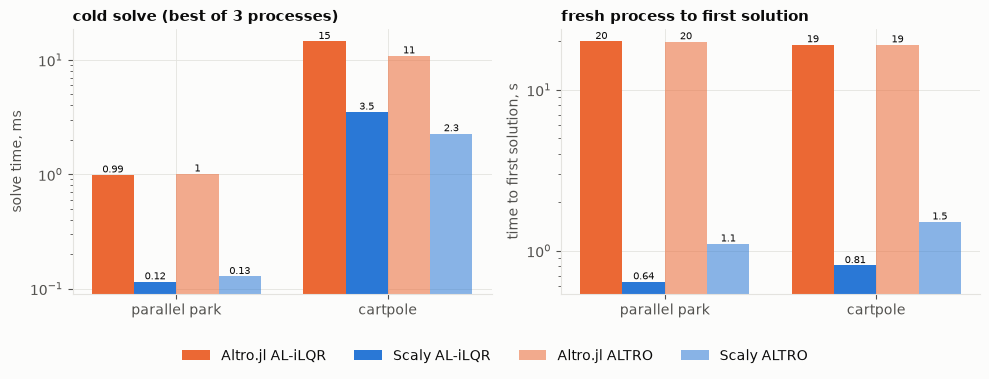

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
problems = ["parallel_park", "cartpole"]
variants = ["altro_al", "scaly_al", "altro_pn", "scaly_pn"]
colors = {"altro_al": "C1", "scaly_al": "C0", "altro_pn": "C1", "scaly_pn": "C0"}
width = 0.2
for ax, key, label in [(axes[0], "time_min", "solve time, ms"), (axes[1], None, "time to first solution, s")]:
  for i, v in enumerate(variants):
    vals = []
    for p in problems:
      r = next(r for r in rows if r["problem"] == p and r["variant"] == v)
      vals.append(1e3 * r["time_min"] if key else first_solve(r))
    bars = ax.bar(np.arange(2) + (i - 1.5) * width, vals, width, color=colors[v], alpha=1.0 if v.endswith("al") else 0.55, label=names[v])
    for b, val in zip(bars, vals):
      ax.annotate(f"{val:.2g}", (b.get_x() + b.get_width() / 2, b.get_height()), ha="center", va="bottom", fontsize=7)
  ax.set_yscale("log")
  ax.set_xticks(np.arange(2), ["parallel park", "cartpole"])
  ax.set_ylabel(label)
axes[0].set_title("cold solve (best of 3 processes)")
axes[1].set_title("fresh process to first solution")
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.06))
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

The trajectories, Altro.jl's (dashed) under Scaly's (solid):

/var/folders/mc/38r0ggmx49l2jwwk6k9nc63h0000gn/T/ipykernel_93212/402616373.py:36: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


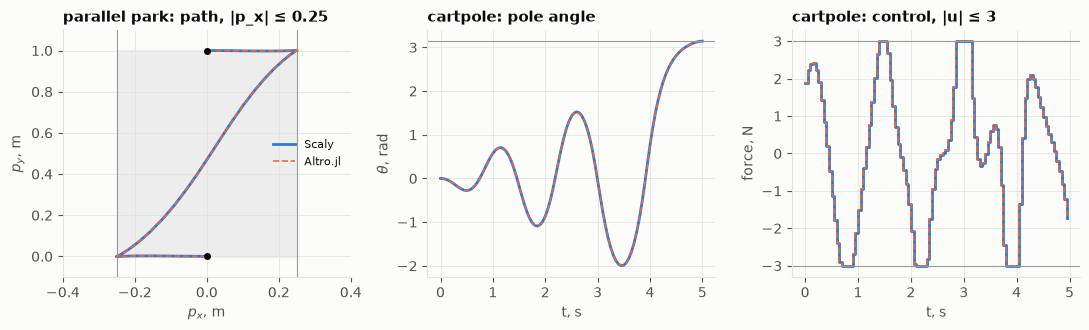

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
pp_s = next(r for r in rows if r["problem"] == "parallel_park" and r["variant"] == "scaly_pn")
pp_a = next(r for r in rows if r["problem"] == "parallel_park" and r["variant"] == "altro_pn")
X, Xa = np.asarray(pp_s["X"]), np.asarray(pp_a["X"])
ax = axes[0]
ax.axvspan(-0.25, 0.25, ymin=0.08, ymax=0.92, color="0.93", zorder=0)
for xb in (-0.25, 0.25):
  ax.axvline(xb, color="0.6", lw=0.8)
ax.plot(X[:, 0], X[:, 1], "C0", lw=2, label="Scaly")
ax.plot(Xa[:, 0], Xa[:, 1], "C1--", lw=1.2, label="Altro.jl")
ax.plot([0, 0], [0, 1], "k.", ms=8)
ax.set_xlim(-0.4, 0.4)
ax.set_ylim(-0.1, 1.1)
ax.set_xlabel("$p_x$, m")
ax.set_ylabel("$p_y$, m")
ax.set_title("parallel park: path, |p_x| ≤ 0.25")
ax.legend(frameon=False, loc="center right", fontsize=8)
cp_s = next(r for r in rows if r["problem"] == "cartpole" and r["variant"] == "scaly_pn")
cp_a = next(r for r in rows if r["problem"] == "cartpole" and r["variant"] == "altro_pn")
Xc, Xca = np.asarray(cp_s["X"]), np.asarray(cp_a["X"])
t = np.linspace(0, 5, Xc.shape[0])
axes[1].plot(t, Xc[:, 1], "C0", lw=2)
axes[1].plot(t, Xca[:, 1], "C1--", lw=1.2)
axes[1].axhline(np.pi, color="0.6", lw=0.8)
axes[1].set_xlabel("t, s")
axes[1].set_ylabel(r"$\theta$, rad")
axes[1].set_title("cartpole: pole angle")
Uc, Uca = np.asarray(cp_s["U"])[:, 0], np.asarray(cp_a["U"])[: len(cp_s["U"]), 0]
axes[2].step(t[:-1], Uc, "C0", lw=2, where="post")
axes[2].step(t[:-1], Uca, "C1--", lw=1.2, where="post")
axes[2].axhline(3, color="0.6", lw=0.8)
axes[2].axhline(-3, color="0.6", lw=0.8)
axes[2].set_xlabel("t, s")
axes[2].set_ylabel("force, N")
axes[2].set_title("cartpole: control, |u| ≤ 3")
fig.tight_layout()
plt.show()

## Findings

- **The same algorithm, the same iterates.** On both problems and in both configurations, Scaly's
  solver takes Altro.jl's iteration counts (18, 112, 93), reaches the same violation to every printed
  digit, and returns the same trajectory to 1e-10 or better. The objective recomputed from each side's
  trajectory agrees to all ten digits shown. This holds because `al_ilqr.py` follows Altro.jl's source,
  not the paper, down to its line-search bounds, its regularization schedule and its gradient measure.
- **Faster everywhere.** A cold solve is 7.9 to 8.6x faster on the parallel park and 4.1 to 4.8x on
  the cartpole, best of three fresh processes. That meets the plan's success criterion on these two
  problems: the same local optimum in less wall time than current Altro.jl.
- **Why the cartpole gains less.** Its line search needs 3.5 rollouts per iLQR iteration against the
  parallel park's 1.4 (391 against 25 in all, counted with a scratch variant of the solver). A rollout
  is the cheap part of an iteration on either side; the derivative expansions of the backward pass,
  ForwardDiff on StaticArrays in Julia against straight-line AD code in Scaly, are where the gap is.
  That is the likely reading, not a measured split.
- **Time to the first solution**: 19 to 20 s for Altro.jl (package load, problem setup, and a first
  solve that compiles) against 0.6 to 1.5 s for Scaly (import, build, C generation, compile).
- **The projection's cost is in code size.** Scaly's projected Newton factors a KKT matrix of about
  800 (parallel park) and 1100 (cartpole) rows with a generated sparse `L D L'`: the C grows from 44 to
  348 kB and the workspace from none to 18 788 doubles for the cartpole. Altro.jl's projection
  allocates (204 and 404 allocations per solve; its augmented Lagrangian allocates nothing).
- **Not done**: the paper's other problems (escape, the quadrotor maze, the Kuka arm) and its DIRCOL
  column (CS-13).